# Statistics II Practice – Project Cycle 1

## 0. Setup

In [1]:
# 載入 numpy 套件
import numpy as np

# 載入 pandas 套件
import pandas as pd

# 載入 matplotlib.pyplot 套件
import matplotlib.pyplot as plt

# 設定一個「隨機種子」，這能確保每次抽樣或隨機算出來的結果都一模一樣
SEED = 777  

# 把我們剛剛設定的種子號碼，交給 numpy 的隨機產生器
np.random.seed(SEED)
# 讓 matplotlib 支援顯示中文 (Windows 電腦請用微軟正黑體)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 

# 讓圖表中的負號可以正常顯示
plt.rcParams['axes.unicode_minus'] = False

## 1. Load and Inspect the Dataset

### 1) Load the CSV into a DataFrame named `df`  

In [2]:
# TO DO: 載入資料集
# 用 pd (pandas) 的 read_csv 功能，把 'Diabetes.csv' 這個檔案讀進來，並且存進一個叫做 df (DataFrame的縮寫) 的變數裡
df = pd.read_csv('Diabetes.csv')

### 2) Display the first 5 rows  

In [3]:
# df.head() 印出這個表格的「前 5 筆」資料
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 3) Report: number of rows, number of columns  

In [4]:
# TO DO: 顯示資料集的維度 (列數, 欄位數)
# df.shape 會告訴我們這個表格有「幾列(幾筆資料)」和「幾行(幾個欄位)」
print(df.shape)

(768, 9)


### 4) Check data types  

In [5]:
# TO DO: 檢查資料型態與非空值數量
# df.info() 會列出所有的欄位名稱，告訴我們裡面是不是數字 (int/float)，以及有沒有漏填的空白資料 (null)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### Interpretation: 

The dataset contains **768 observations and 9 variables**.
The outcome variable is **Outcome**, which indicates whether a person has diabetes (1) or not (0).
Most variables such as Pregnancies, Glucose, BloodPressure, and Age are **discrete numerical variables**.
Variables like **BMI** and **DiabetesPedigreeFunction** are **continuous variables**.
The outcome variable is **binary**, since it only has two possible values (0 or 1).

此資料集包含 768 個觀測值和 9 個變數。結果變數為 Outcome，表示一個人是否患有糖尿病（1 表示患有糖尿病，0 表示未患糖尿病）。大多數變量，例如 Pregnancies（妊娠）、Glucose（血糖）、Blood Pressure（血壓）和 Age（年齡），均為離散數值變數。 BMI 和 DiabetesPedigreeFunction（糖尿病譜系）等變數為連續變數。結果變數為二元變量，因為它只有兩個可能的值（0 或 1）。

## 2. Data Quality Checks

### 1) Summary statistics (`describe`)  

In [6]:
# TO DO: 產生摘要統計
# df.describe() 會幫我們算好每個欄位的平均數、標準差、最大值、最小值等統計數據
summary = df.describe()

# 把算好的結果印出來看
summary

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2) Missing value check  

In [7]:
# TO DO: 計算缺失值 (NaN) 的數量
# df.isna() 會檢查每個格子是不是空白的，.sum() 會把它們全部加總起來
missing_counts = df.isna().sum()

# 印出加總結果
missing_counts

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### 3) Identify suspicious values (e.g., zeros where impossible/unlikely)  

In [8]:
# TO DO: Count the number of 0 values in specific variables 
# 💡TO DO: 計算特定變數裡，數值為 0 的數量 (因為有些醫療數據不可能是 0，0 代表可能忘記填寫)

# Store the names of the columns we want to check in a list
# 💡我們先把想要檢查的欄位名稱，存成一個清單
vars_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age", "DiabetesPedigreeFunction"]

# Find the data in these columns that are equal to 0, and sum up their counts (.sum)
# 💡找出這些欄位裡面等於 0 的資料，然後把它們的數量加總起來 (.sum)
zero_counts = (df[vars_to_check] == 0).sum()

# Create a dictionary to map English names to bilingual names
# 💡建立一個字典，準備把純英文標籤換成中英雙語對照
rename_dict = {
    "Glucose": "Glucose (血糖)",
    "BloodPressure": "BloodPressure (血壓)",
    "SkinThickness": "SkinThickness (皮脂厚度)",
    "Insulin": "Insulin (胰島素)",
    "BMI": "BMI (體重指數)",
    "Age": "Age (年齡)",
    "DiabetesPedigreeFunction": "DiabetesPedigreeFunction (糖尿病家族史)"
}

# Rename the index of the result and print it
# 💡利用 .rename() 幫算出來的結果換上雙語標籤，然後印出來
zero_counts_display = zero_counts.rename(index=rename_dict)
zero_counts_display

Glucose (血糖)                           5
BloodPressure (血壓)                    35
SkinThickness (皮脂厚度)                 227
Insulin (胰島素)                        374
BMI (體重指數)                            11
Age (年齡)                               0
DiabetesPedigreeFunction (糖尿病家族史)      0
dtype: int64

#### Interpretation: 

The missing value check shows that there are no missing values in the dataset, since all variables have zero missing counts.
However, several variables contain suspicious values of 0, including Glucose, BloodPressure, SkinThickness, Insulin, and BMI.
In real medical measurements, these variables are unlikely to have a value of zero.
For example, a blood glucose level or blood pressure of zero is not realistic.
Therefore, these zero values may actually represent missing or unrecorded measurements in the dataset.
If these values are treated as real measurements, they may affect statistical analysis and lead to misleading results.
Further data cleaning or replacement methods may be needed before building models or performing deeper analysis.

缺失值檢查顯示資料集中不存在缺失值，因為所有變數的缺失計數均為零。然而，有幾個變數包含可疑的零值，包括血糖、血壓、皮膚厚度、胰​​島素和BMI。在實際的醫學測量中，這些變數不太可能為零。例如，血糖或血壓為零是不切實際的。因此，這些零值實際上可能代表資料集中缺失或未記錄的測量值。如果將這些零值視為真實測量值，則可能會影響統計分析並導致誤導性結果。在建立模型或進行更深入的分析之前，可能需要進一步的資料清理或替換方法。

## 3. Required Visualizations (Matplotlib Default)

### A) Histogram of Glucose  

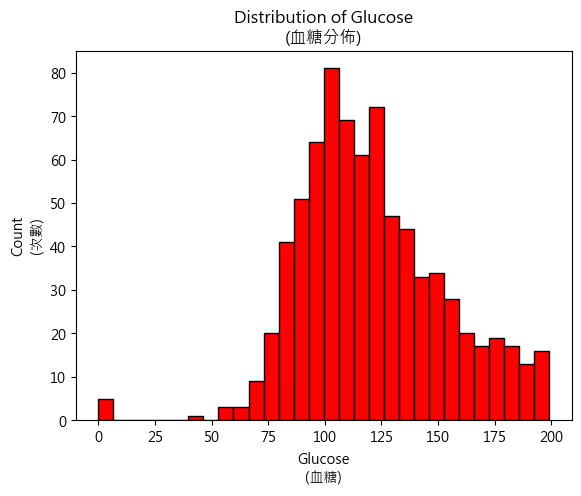

In [9]:
# 準備一張新的空白畫布
plt.figure()

# TO DO: 畫出 Glucose (血糖) 的直方圖
# df['Glucose'] 代表我們只拿出血糖這個欄位，bins=30 代表我們要把數據切成 30 個區塊來統計
plt.hist(df['Glucose'], bins=30, color='red', edgecolor='black')

# 設定圖表的標題
plt.title("Distribution of Glucose\n(血糖分佈)")

# 設定 X 軸的名稱
plt.xlabel("Glucose\n(血糖)")

# 設定 Y 軸的名稱
plt.ylabel("Count\n(次數)")

# 把畫好的圖顯示出來
plt.show()

#### Interpretation: 

The histogram shows a slightly right-skewed distribution of glucose levels. Most observations are centered around moderate glucose values, roughly between 100 and 140. The values spread across a wide range from very low to high glucose levels. A few unusually low values, including zeros, appear as potential outliers and may represent missing or invalid measurements.

直方圖顯示血糖值呈現輕微右偏分佈。大多數觀測值集中在中等血糖值附近，大致在 100 到 140 之間。這些數值分佈範圍很廣，從極低到極高都有。一些異常低的數值，包括零值，可能是離群值，也可能代表缺失或無效的測量值。

### B) Histogram of BMI  

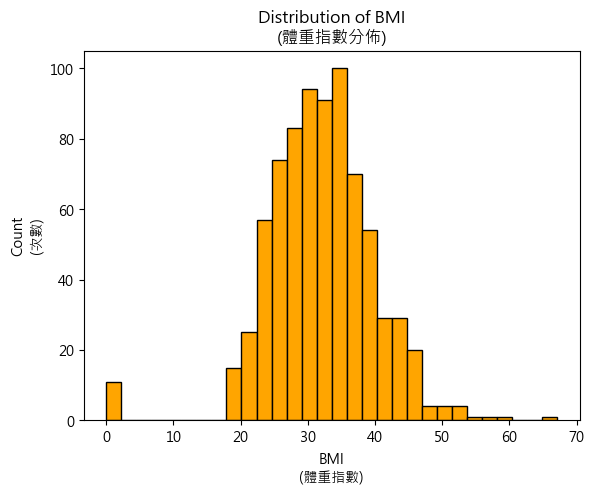

In [10]:
# 準備一張新的空白畫布
plt.figure()

# TO DO: 畫出 BMI 的直方圖
plt.hist(df['BMI'], bins=30, color='orange', edgecolor='black')

# 設定圖表的標題與 X, Y 軸名稱
plt.title("Distribution of BMI\n(體重指數分佈)")
plt.xlabel("BMI\n(體重指數)")
plt.ylabel("Count\n(次數)")

# 顯示圖表
plt.show()

#### Interpretation: 

The histogram of BMI shows a slightly right-skewed distribution. Most BMI values are centered around approximately 25 to 35. The values spread across a moderate range, from very low to relatively high BMI levels. A few unusually low values, including zeros, appear as potential outliers and may represent missing or invalid measurements.

BMI 直方圖顯示其分佈略為右偏。大多數 BMI 值集中在 25 到 35 之間。這些數值分佈範圍適中，從極低到相對較高的 BMI 水準都有涉及。少數異常低的值，包括零值，可能是離群值，也可能代表缺失或無效的測量資料。

### C) Boxplot of Glucose by Outcome  

C:\Users\user\AppData\Local\Temp\ipykernel_26840\616340095.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["Outcome=0\n(無糖尿病)", "Outcome=1\n(有糖尿病)"])


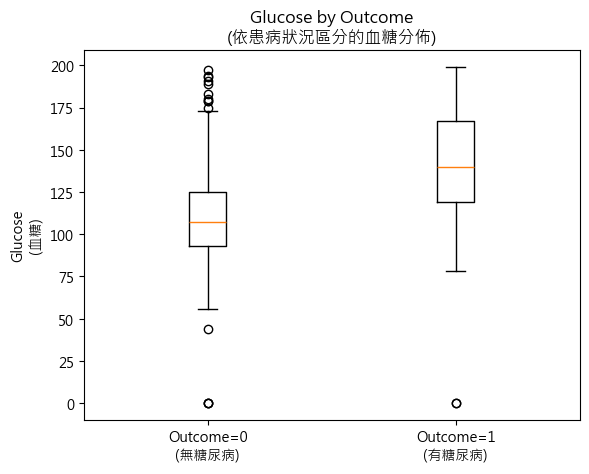

In [11]:
# TO DO: 把資料分成兩群 (有糖尿病 vs 沒糖尿病)

# 把 Outcome 欄位等於 0 (沒病) 的人的 Glucose (血糖) 數值全部抓出來，存到一個叫做 g0 的變數裡
g0 = df[df['Outcome'] == 0]['Glucose']

# 把 Outcome 欄位等於 1 (有病) 的人的 Glucose (血糖) 數值全部抓出來，存到一個叫做 g1 的變數裡
g1 = df[df['Outcome'] == 1]['Glucose']


# ================= 畫圖與字體設定部分 =================

# 準備一張全新的空白畫布，避免跟前面的圖表重疊在一起
plt.figure()

# 設定中文字體，讓圖表可以正常顯示中文，避免變成方塊亂碼 (Windows 系統適用微軟正黑體)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 

# 設定讓圖表中的負號可以正常顯示 (這是設定中文字體時的標準防錯配備)
plt.rcParams['axes.unicode_minus'] = False 


# TO DO: 畫出盒鬚圖來比較這兩群

# 使用 plt.boxplot 畫出盒鬚圖。把 g0 和 g1 裝進中括號裡放進去畫
# labels 參數用來設定 X 軸底下的文字，利用 \n 讓第一行顯示英文、第二行顯示中文
plt.boxplot([g0, g1], labels=["Outcome=0\n(無糖尿病)", "Outcome=1\n(有糖尿病)"])

# 設定圖表最上方的標題，一樣利用 \n 達成中英雙語對照
plt.title("Glucose by Outcome\n(依患病狀況區分的血糖分佈)")

# 設定 Y 軸的名稱，利用 \n 達成中英雙語對照
plt.ylabel("Glucose\n(血糖)")

# 把畫好、設定好所有文字的圖表，正式顯示在螢幕上
plt.show()

#### Interpretation: 

The boxplot shows that the median glucose level for individuals with diabetes (Outcome = 1) is higher than for those without diabetes (Outcome = 0). The diabetes group also appears to have greater variability in glucose values. Although there is some overlap between the two groups, higher glucose levels are more common among individuals with diabetes. This suggests that glucose level is strongly related to the diabetes outcome.

箱線圖顯示，糖尿病患者（結果=1）的中位血糖值高於非糖尿病患者（結果=0）。糖尿病組的血糖值波動性也較大。儘管兩組之間存在部分重疊，但糖尿病患者中血糖水平較高的情況更為普遍。這表明血糖水平與糖尿病結局密切相關。

### D) Scatter: Age vs BMI (use color/marker by Outcome)

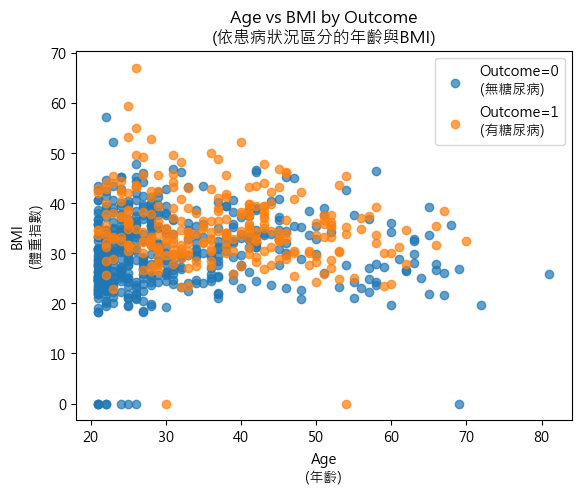

In [12]:
# TO DO: 把整份表格分成兩群
# 抓出 Outcome 為 0 (沒病) 的所有資料，存成 df0
df0 = df[df['Outcome'] == 0]

# 抓出 Outcome 為 1 (有病) 的所有資料，存成 df1
df1 = df[df['Outcome'] == 1]

# 準備新畫布
plt.figure()

# TO DO: 畫出散佈圖
# 畫第一群 (沒病)：X軸放年齡，Y軸放BMI。alpha=0.7 是讓點變成半透明，label是圖例名稱
plt.scatter(df0['Age'], df0['BMI'], alpha=0.7, label='Outcome=0\n(無糖尿病)')

# 畫第二群 (有病)：X軸放年齡，Y軸放BMI
plt.scatter(df1['Age'], df1['BMI'], alpha=0.7, label='Outcome=1\n(有糖尿病)')

# 設定標題、X軸與Y軸名稱
plt.title("Age vs BMI by Outcome\n(依患病狀況區分的年齡與BMI)")
plt.xlabel("Age\n(年齡)")
plt.ylabel("BMI\n(體重指數)")

# 顯示圖例 (也就是剛剛設定的 label)
plt.legend()

# 顯示圖表
plt.show()

#### Interpretation: 

The scatter plot shows the relationship between age and BMI for individuals with and without diabetes. The two groups overlap considerably, and there is no clear separation between them. However, individuals with diabetes tend to appear more frequently at higher BMI values and older ages. This suggests that age and BMI may be related to diabetes, but they do not perfectly distinguish the two groups.

散點圖顯示了糖尿病患者和非糖尿病患者的年齡與BMI之間的關係。兩組人群的數據重疊度較高，界線並不清晰。然而，糖尿病患者往往更常見於BMI較高、年齡較大的人。這表明年齡和BMI可能與糖尿病有關，但它們並不能完美區分這兩組人群。

## 4. Group Comparison Summary (Descriptive)

### 1) Compute group means for Glucose, BMI, Age by Outcome  

In [13]:
# TO DO: 算群組平均值
# 按照 Outcome (有無患病) 來分群 (.groupby)，然後計算每一群所有數字欄位的平均值 (.mean())
summary_means = df.groupby('Outcome').mean()

#輸出出結果
summary_means

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


#### Interpretation: 

The group comparison shows that individuals with diabetes (Outcome = 1) generally have higher mean values for Glucose, BMI, and Age compared to those without diabetes. Among these variables, Glucose shows the largest difference between the two groups. BMI and Age also appear higher for the diabetes group, but the differences are smaller than for Glucose. Based on this descriptive comparison, Glucose and BMI seem most strongly associated with the diabetes outcome. However, these results only show associations and do not imply causality. Further statistical analysis would be required to confirm these relationships.

組間比較顯示，糖尿病患者（結局=1）的血糖、BMI和年齡平均值通常高於非糖尿病患者。在這些變項中，血糖在兩組間的差異最大。糖尿病組的BMI和年齡也較高，但差異小於血糖。基於此描述性比較，血糖和BMI似乎與糖尿病結果的相關性最強。然而，這些結果僅表明存在相關性，並不意味著因果關係。需要進一步的統計分析來證實這些關係。

### 2) Compute mean differences (Outcome=1 minus Outcome=0)  

In [14]:
# TO DO: 計算兩群平均值的差異 (有病 減去 沒病)
# .loc[1] 就是抓出 Outcome=1 (有病) 的那橫列，.loc[0] 是抓出 Outcome=0 (沒病) 的那橫列
mean_diff = summary_means.loc[1] - summary_means.loc[0]

# 輸出相減的結果
mean_diff

Pregnancies                  1.567672
Glucose                     31.277463
BloodPressure                2.640627
SkinThickness                2.500179
Insulin                     31.543821
BMI                          4.838337
DiabetesPedigreeFunction     0.120766
Age                          5.877164
dtype: float64

## 5. Sampling Simulation (Concept Preparation)







### 1) Sample n = 30 observations (with replacement)  

### 2) Compute the sample mean of Glucose  
### 3) Repeat B = 1000 times 

In [15]:
# TO DO: 設定模擬參數
# B = 1000 代表我們要重複抽樣 1000 次
B = 1000

# n = 30 代表我們每一次抽樣，都要抽出 30 個人
n = 30

In [16]:
# 準備一個空的清單，用來收集我們每次算出來的「平均值」
means = []

# 開始一個迴圈，會重複執行 1000 次
for b in range(B):
    
    # TO DO: 進行抽樣
    # 從 Glucose (血糖) 欄位裡，隨機抽出 n(30) 筆資料。replace=True 代表「取後放回」
    sample = df['Glucose'].sample(n=n, replace=True)
    
    # TO DO: 計算這次抽出來的這 30 個人的血糖平均值
    m = sample.mean()
    
    # 把算好的平均值，塞進我們準備好的 means 清單裡面
    means.append(m)

# 把清單轉換成 numpy 的陣列，方便等一下做數學計算
means = np.array(means)

### 4) Plot the distribution of sample means (matplotlib)  

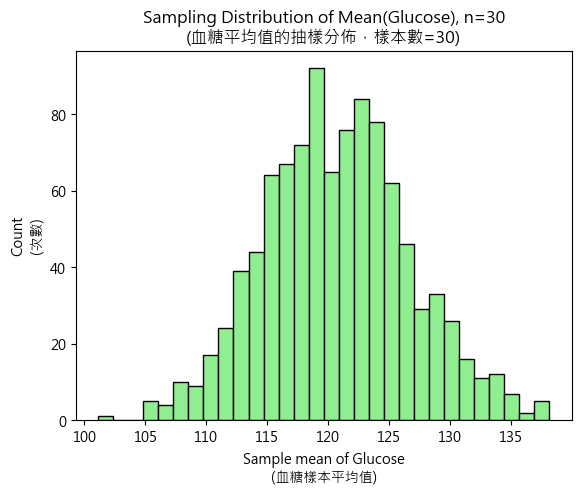

In [17]:
# TO DO: 畫出我們剛剛收集到的 1000 個平均值的直方圖

# 畫出這 1000 個平均值的直方圖 (Histogram)
# means 是我們前面算好的 1000 個平均值，bins=30 代表把數據切成 30 條直條
# color='lightgreen' 設定顏色為淺綠色，edgecolor='black' 讓柱子有黑色的邊框比較清楚
plt.hist(means, bins=30, color='lightgreen', edgecolor='black')

# 設定標題、X軸與Y軸名稱
plt.title("Sampling Distribution of Mean(Glucose), n=30\n(血糖平均值的抽樣分佈，樣本數=30)")
plt.xlabel("Sample mean of Glucose\n(血糖樣本平均值)")
plt.ylabel("Count\n(次數)")

# 把畫好、設定好所有文字的圖表輸出
plt.show()

### 5) Report the mean and standard deviation of the sampling distribution  

In [18]:
# TO DO: 報告這個抽樣分佈的中心點 (平均數) 和 散佈程度 (標準差)
# 算出這 1000 個平均值的「總平均」
center = means.mean()

# 算出這 1000 個平均值的「標準差」 (ddof=1 是為了算樣本標準差)
spread = means.std(ddof=1)

# 輸出結果
center, spread

(np.float64(120.68816666666667), np.float64(5.997945832977023))

#### Interpretation: 

The sampling distribution represents the distribution of sample means obtained from repeated random samples of size 30. Each point in the distribution is the average glucose level from one sample. Compared with the raw Glucose distribution, the sampling distribution is narrower because averages vary less than individual observations. This occurs because averaging reduces random variability across samples. The standard deviation of this distribution reflects the sampling variability of the sample mean. Therefore, it helps quantify the uncertainty when using a sample mean to estimate the population mean.
抽樣分佈代表了從重複抽取大小為 30 的隨機樣本中獲得的樣本平均值的分佈。分佈中的每個點代表一個樣本的平均血糖值。與原始血糖分佈相比，抽樣分佈更窄，因為平均值的波動小於單一觀測值的波動。這是因為平均值降低了樣本間的隨機變異性。此分佈的標準差反映了樣本平均值的抽樣變異性。因此，它有助於量化使用樣本平均值估計總體平均值時的不確定性。

## Extension Plan: 懷孕跟糖尿病確診率的關係
動機： 初步觀察發現「懷孕次數越多，確診率越高」但考慮受試著年齡會影響判斷結果，故此次實驗目的是為了排除干擾項目以得出更全面的結論。

方法：  
1. 先將懷孕次數與確診率數據畫成折線圖
2. 將懷孕次數與年齡數據畫成折線圖
3. 將年齡分組比較懷孕次數是否會影響確診率

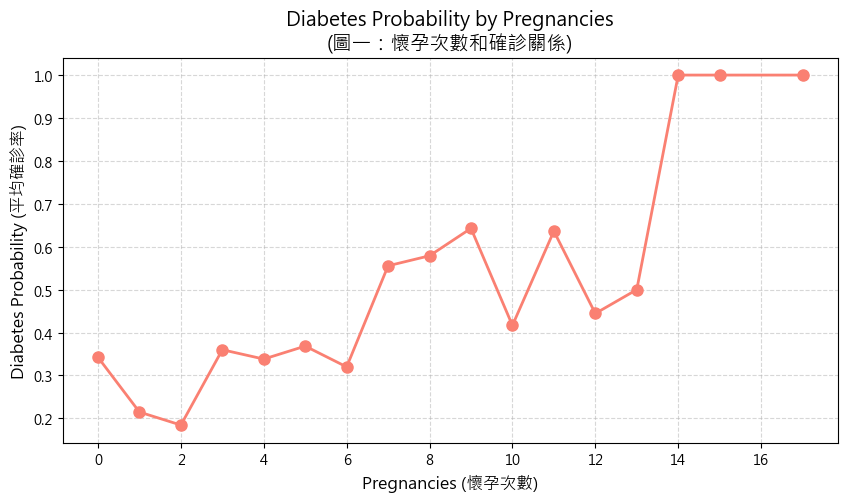

In [19]:
#### ：建立懷孕次數與確診率的直觀關係

import matplotlib.pyplot as plt

# 1. 計算每個懷孕次數的「平均確診率」
preg_outcome_rate = df.groupby('Pregnancies')['Outcome'].mean()

# 2. 畫出折線圖來看趨勢
plt.figure(figsize=(10, 5))
plt.plot(preg_outcome_rate.index, preg_outcome_rate.values, marker='o', color='salmon', linewidth=2, markersize=8)

# 設定標題、X軸與Y軸名稱
plt.title('Diabetes Probability by Pregnancies\n(圖一：懷孕次數和確診關係)', fontsize=14)
plt.xlabel('Pregnancies (懷孕次數)', fontsize=12)
plt.ylabel('Diabetes Probability (平均確診率)', fontsize=12)

# 讓 X 軸的刻度乾淨一點
#0開始18結束一次跳2
plt.xticks(range(0, 18, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

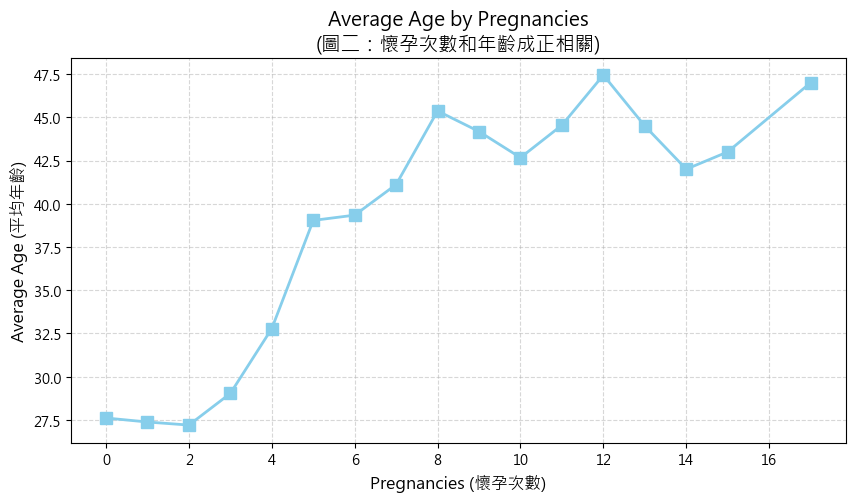

In [20]:
# [我的筆記] 延伸研究首部曲 (圖二)：揭露真相——年齡與懷孕次數的強烈正相關

# 1. 計算每個懷孕次數對應的「平均年齡」
preg_age_mean = df.groupby('Pregnancies')['Age'].mean()

# 2. 畫出折線圖來對比
plt.figure(figsize=(10, 5))
plt.plot(preg_age_mean.index, preg_age_mean.values, marker='s', color='skyblue', linewidth=2, markersize=8)

plt.title('Average Age by Pregnancies\n(圖二：懷孕次數和年齡成正相關)', fontsize=14)
plt.xlabel('Pregnancies (懷孕次數)', fontsize=12)
plt.ylabel('Average Age (平均年齡)', fontsize=12)

plt.xticks(range(0, 18, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_26840\3502108441.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = df.pivot_table(values='Outcome', index='Age_Group', columns='Preg_Group', aggfunc='mean')


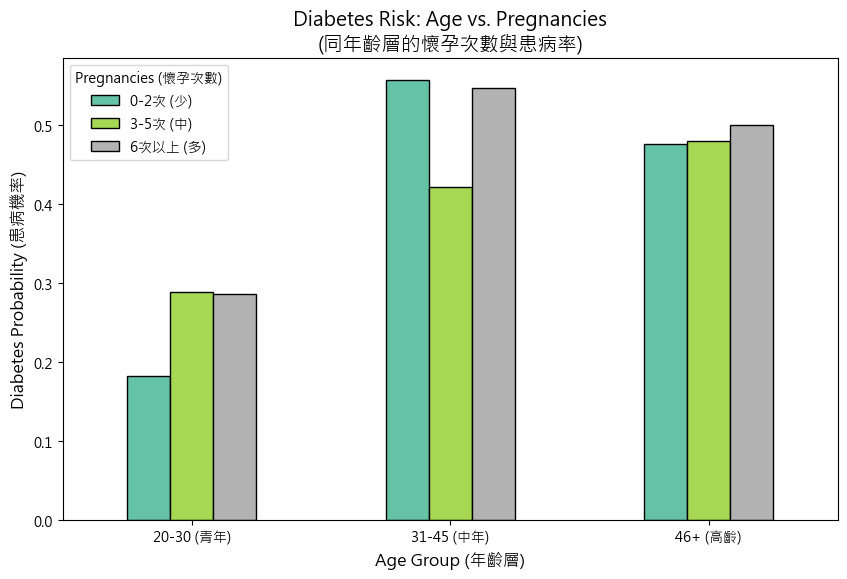

Preg_Group,0-2次 (少),3-5次 (中),6次以上 (多)
Age_Group,,,
20-30 (青年),0.182456,0.288288,0.285714
31-45 (中年),0.558140,0.421875,0.547619
46+ (高齡),0.476190,0.480000,0.500000


In [21]:
# 懷孕次數越多是否越容易得糖尿病?
# 利用「分層分析」排除「年齡」干擾變數 (Confounding Variable)

import matplotlib.pyplot as plt

# 1. 將年齡分成三個世代 (青年、中年、高齡)
age_bins = [20, 31, 46, 100]
age_labels = ['20-30 (青年)', '31-45 (中年)', '46+ (高齡)']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# 2. 將懷孕次數分成三組 (少、中、多)
preg_bins = [-1, 2, 5, 20]
preg_labels = ['0-2次 (少)', '3-5次 (中)', '6次以上 (多)']
df['Preg_Group'] = pd.cut(df['Pregnancies'], bins=preg_bins, labels=preg_labels)

# 3.製作分組圖表：計算「同年齡層」下，不同「懷孕次數」的患病機率
pivot_df = df.pivot_table(values='Outcome', index='Age_Group', columns='Preg_Group', aggfunc='mean')

# 4. 畫出長條圖
pivot_df.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')

plt.title('Diabetes Risk: Age vs. Pregnancies\n(同年齡層的懷孕次數與患病率)', fontsize=14)
plt.xlabel('Age Group (年齡層)', fontsize=12)
plt.ylabel('Diabetes Probability (患病機率)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Pregnancies (懷孕次數)')
plt.show()

# 印出交叉比對的數據表格供參考
pivot_df

In [22]:
#檢查每個分組格子裡面的「真實人數 (count)」小樣本數會導致波動加劇
pivot_count = df.pivot_table(values='Outcome', index='Age_Group', columns='Preg_Group', aggfunc='count')
pivot_count

C:\Users\user\AppData\Local\Temp\ipykernel_26840\2402672777.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_count = df.pivot_table(values='Outcome', index='Age_Group', columns='Preg_Group', aggfunc='count')


Preg_Group,0-2次 (少),3-5次 (中),6次以上 (多)
Age_Group,,,
20-30 (青年),285,111,21
31-45 (中年),43,64,126
46+ (高齡),21,25,72
